In [3]:
import pandas as pd
df = pd.read_csv("cleaned_installments.csv")

In [4]:
df.head()

,Asset ID,Origination Date,Total Advance,Total EMI,Payment Date,Payment Amount
0,264,2024-01-31,17160,20540,2024-02-07,860.0
1,264,2024-01-31,17160,20540,2024-02-14,860.0
2,264,2024-01-31,17160,20540,2024-02-21,860.0
3,264,2024-01-31,17160,20540,2024-02-28,860.0
4,264,2024-01-31,17160,20540,2024-03-06,860.0


## Create Cohort Month


In [5]:
df["Origination Date"] = pd.to_datetime(df["Origination Date"], errors="coerce")
df["Payment Date"] = pd.to_datetime(df["Payment Date"], errors="coerce")

In [6]:
df['Cohort'] = (df["Origination Date"].dt.to_period("M"))
df.head()

,Asset ID,Origination Date,Total Advance,Total EMI,Payment Date,Payment Amount,Cohort
0,264,2024-01-31,17160,20540,2024-02-07,860.0,2024-01
1,264,2024-01-31,17160,20540,2024-02-14,860.0,2024-01
2,264,2024-01-31,17160,20540,2024-02-21,860.0,2024-01
3,264,2024-01-31,17160,20540,2024-02-28,860.0,2024-01
4,264,2024-01-31,17160,20540,2024-03-06,860.0,2024-01


## Calculate Elapsed Months


In [7]:
df["MOB"] = ((df["Payment Date"].dt.year - df["Origination Date"].dt.year) * 12 + (df["Payment Date"].dt.month - df["Origination Date"].dt.month))


In [8]:
print(
    df[
        [
            "Origination Date",
            "Payment Date",
            "MOB"
        ]
    ].head(20)
)

   Origination Date Payment Date  MOB
0        2024-01-31   2024-02-07    1
1        2024-01-31   2024-02-14    1
2        2024-01-31   2024-02-21    1
3        2024-01-31   2024-02-28    1
4        2024-01-31   2024-03-06    2
5        2024-01-31   2024-03-13    2
6        2024-01-31   2024-03-20    2
7        2024-01-31   2024-03-27    2
8        2024-01-31   2024-04-03    3
9        2024-01-31   2024-04-10    3
10       2024-01-29   2024-02-05    1
11       2024-01-29   2024-02-12    1
12       2024-01-29   2024-02-19    1
13       2024-01-29   2024-02-26    1
14       2024-01-29   2024-03-04    2
15       2024-01-29   2024-03-11    2
16       2024-01-29   2024-03-18    2
17       2024-01-29   2024-03-25    2
18       2024-01-29   2024-04-01    3
19       2024-01-29   2024-04-08    3


## Check Cohort Count


In [9]:
print(
    df["Cohort"]
    .value_counts()
    .sort_index()
)

Cohort
2024-01     114
2024-02     238
2024-03    1495
2024-04     667
2024-05     385
2024-06     751
2024-07     402
2024-08     584
2024-09     744
2024-10     685
2024-11     582
2024-12     192
2025-09      13
2025-10       4
2026-01       1
Freq: M, Name: count, dtype: int64


## Unique Assets ID per Cohort


In [10]:
cohort_assets = (
    df.groupby("Cohort")["Asset ID"]
      .nunique()
      .reset_index(name="Unique Assets")
)

print(cohort_assets.head())

    Cohort  Unique Assets
0  2024-01              6
1  2024-02             11
2  2024-03             64
3  2024-04             32
4  2024-05             16


## Calculate Total Advance per Cohort


In [11]:
# create unique asset table
asset_master = (
    df[
        [
            "Asset ID",
            "Cohort",
            "Total Advance"
        ]
    ]
    .drop_duplicates(subset=["Asset ID"])
)

In [12]:
print(asset_master.head())
print(asset_master.shape)

    Asset ID   Cohort  Total Advance
0        264  2024-01          17160
10       324  2024-01          20000
34       336  2024-01          27500
45       567  2024-01          17160
69       722  2024-02          16100
(349, 3)


In [13]:
df.head()

,Asset ID,Origination Date,Total Advance,Total EMI,Payment Date,Payment Amount,Cohort,MOB
0,264,2024-01-31,17160,20540,2024-02-07,860.0,2024-01,1
1,264,2024-01-31,17160,20540,2024-02-14,860.0,2024-01,1
2,264,2024-01-31,17160,20540,2024-02-21,860.0,2024-01,1
3,264,2024-01-31,17160,20540,2024-02-28,860.0,2024-01,1
4,264,2024-01-31,17160,20540,2024-03-06,860.0,2024-01,2


## Calculate Cohort Total Advance


In [14]:
cohort_advance = (
    asset_master
    .groupby("Cohort", as_index=False)
    ["Total Advance"]
    .sum()
)

In [15]:
cohort_advance = cohort_advance.rename(
    columns={
        "Total Advance": "Cohort Total Advance"
    }
)
cohort_advance

,Cohort,Cohort Total Advance
0,2024-01,102945
1,2024-02,136095
2,2024-03,795665
3,2024-04,368935
4,2024-05,224805
5,2024-06,447855
6,2024-07,286900
7,2024-08,325990
8,2024-09,408306
9,2024-10,461204


In [16]:
print("Number of cohorts:", df["Cohort"].nunique())

print(
    "Advance table cohorts:",
    cohort_advance["Cohort"].nunique()
)

Number of cohorts: 15
Advance table cohorts: 15


# MOIC= Payment Collections In Period / Total Advance​


In [17]:
cohort_payments = (
    df.groupby(
        ["Cohort", "MOB"],
        as_index=False
    )["Payment Amount"]
    .sum()
)
cohort_payments = cohort_payments.rename(
    columns={
        "Payment Amount": "Period Collection"
    }
)
cohort_payments

,Cohort,MOB,Period Collection
0,2024-01,1,23498.0
1,2024-01,2,24097.0
2,2024-01,3,39580.0
3,2024-01,4,12689.0
4,2024-01,5,11843.0
...,...,...,...
158,2025-10,2,1500.0
159,2025-10,3,1940.0
160,2025-10,4,1950.0
161,2025-10,25,2000.0


## Merge Cohort Advance with Cohort Payments


In [18]:
cohort_moic = cohort_payments.merge(
    cohort_advance,
    on="Cohort",
    how="left"
)
cohort_moic

,Cohort,MOB,Period Collection,Cohort Total Advance
0,2024-01,1,23498.0,102945
1,2024-01,2,24097.0,102945
2,2024-01,3,39580.0,102945
3,2024-01,4,12689.0,102945
4,2024-01,5,11843.0,102945
...,...,...,...,...
158,2025-10,2,1500.0,8249
159,2025-10,3,1940.0,8249
160,2025-10,4,1950.0,8249
161,2025-10,25,2000.0,8249


## Calculate Payment MOIC


In [19]:
cohort_moic["Payment MOIC"] = (
    cohort_moic["Period Collection"]
    /
    cohort_moic["Cohort Total Advance"]
)
cohort_moic

,Cohort,MOB,Period Collection,Cohort Total Advance,Payment MOIC
0,2024-01,1,23498.0,102945,0.228258
1,2024-01,2,24097.0,102945,0.234076
2,2024-01,3,39580.0,102945,0.384477
3,2024-01,4,12689.0,102945,0.123260
4,2024-01,5,11843.0,102945,0.115042
...,...,...,...,...,...
158,2025-10,2,1500.0,8249,0.181840
159,2025-10,3,1940.0,8249,0.235180
160,2025-10,4,1950.0,8249,0.236392
161,2025-10,25,2000.0,8249,0.242454


## Calculate Cumulative Collection


In [20]:
cohort_moic = cohort_moic.sort_values(
    ["Cohort", "MOB"]
)

cohort_moic["Cumulative Collection"] = (
    cohort_moic
    .groupby("Cohort")
    ["Period Collection"]
    .cumsum()
)
cohort_moic

,Cohort,MOB,Period Collection,Cohort Total Advance,Payment MOIC,Cumulative Collection
0,2024-01,1,23498.0,102945,0.228258,23498.0
1,2024-01,2,24097.0,102945,0.234076,47595.0
2,2024-01,3,39580.0,102945,0.384477,87175.0
3,2024-01,4,12689.0,102945,0.123260,99864.0
4,2024-01,5,11843.0,102945,0.115042,111707.0
...,...,...,...,...,...,...
158,2025-10,2,1500.0,8249,0.181840,1500.0
159,2025-10,3,1940.0,8249,0.235180,3440.0
160,2025-10,4,1950.0,8249,0.236392,5390.0
161,2025-10,25,2000.0,8249,0.242454,7390.0


## Calculate Cumulative MOIC

- Cumulative MOIC = Cumulative Collection/Total Advance​


In [21]:
cohort_moic["Cumulative MOIC"] = (
    cohort_moic["Cumulative Collection"]
    /
    cohort_moic["Cohort Total Advance"]
)

In [ ]:
cohort_moic.to_csv("cohort_moic.csv", index=False)
cohort_moic

,Cohort,MOB,Period Collection,Cohort Total Advance,Payment MOIC,Cumulative Collection,Cumulative MOIC
0,2024-01,1,23498.0,102945,0.228258,23498.0,0.228258
1,2024-01,2,24097.0,102945,0.234076,47595.0,0.462334
2,2024-01,3,39580.0,102945,0.384477,87175.0,0.846811
3,2024-01,4,12689.0,102945,0.123260,99864.0,0.970071
4,2024-01,5,11843.0,102945,0.115042,111707.0,1.085113
...,...,...,...,...,...,...,...
158,2025-10,2,1500.0,8249,0.181840,1500.0,0.181840
159,2025-10,3,1940.0,8249,0.235180,3440.0,0.417020
160,2025-10,4,1950.0,8249,0.236392,5390.0,0.653413
161,2025-10,25,2000.0,8249,0.242454,7390.0,0.895866


In [29]:
cohort_summary = (
    cohort_moic
    .sort_values(["Cohort", "MOB"])
    .groupby("Cohort")
    .tail(1)
    [
        [
            "Cohort",
            "Cohort Total Advance",
            "Cumulative Collection",
            "Cumulative MOIC"
        ]
    ]
    .reset_index(drop=True)
)
cohort_summary = cohort_summary.rename(
    columns={
        "Cumulative Collection": "Total Collection",
        "Cumulative MOIC": "Final MOIC"
    }
)
cohort_summary


,Cohort,Cohort Total Advance,Total Collection,Final MOIC
0,2024-01,102945,119150.0,1.157414
1,2024-02,136095,181074.0,1.330497
2,2024-03,795665,1030222.0,1.294794
3,2024-04,368935,506270.0,1.372247
4,2024-05,224805,293500.0,1.305576
5,2024-06,447855,583578.0,1.303051
6,2024-07,286900,381188.0,1.328644
7,2024-08,325990,445617.0,1.366965
8,2024-09,408306,567657.0,1.390273
9,2024-10,461204,614090.0,1.331493


In [30]:
asset_count = (
    asset_master
    .groupby("Cohort")["Asset ID"]
    .nunique()
    .reset_index(name="Asset Count")
)

cohort_summary = cohort_summary.merge(
    asset_count,
    on="Cohort",
    how="left"
)

cohort_summary = cohort_summary[
    [
        "Cohort",
        "Asset Count",
        "Cohort Total Advance",
        "Total Collection",
        "Final MOIC"
    ]
]
# cohort_summary
cohort_summary.to_csv("cohort_summary.csv", index=False)

## Making Cohort Summery Chart


In [31]:
cohort_summary.sort_values(
    "Final MOIC",
    ascending=False
)

,Cohort,Asset Count,Cohort Total Advance,Total Collection,Final MOIC
8,2024-09,37,408306,567657.0,1.390273
3,2024-04,32,368935,506270.0,1.372247
7,2024-08,28,325990,445617.0,1.366965
9,2024-10,37,461204,614090.0,1.331493
1,2024-02,11,136095,181074.0,1.330497
6,2024-07,20,286900,381188.0,1.328644
4,2024-05,16,224805,293500.0,1.305576
5,2024-06,32,447855,583578.0,1.303051
2,2024-03,64,795665,1030222.0,1.294794
12,2025-09,1,9749,12180.0,1.249359


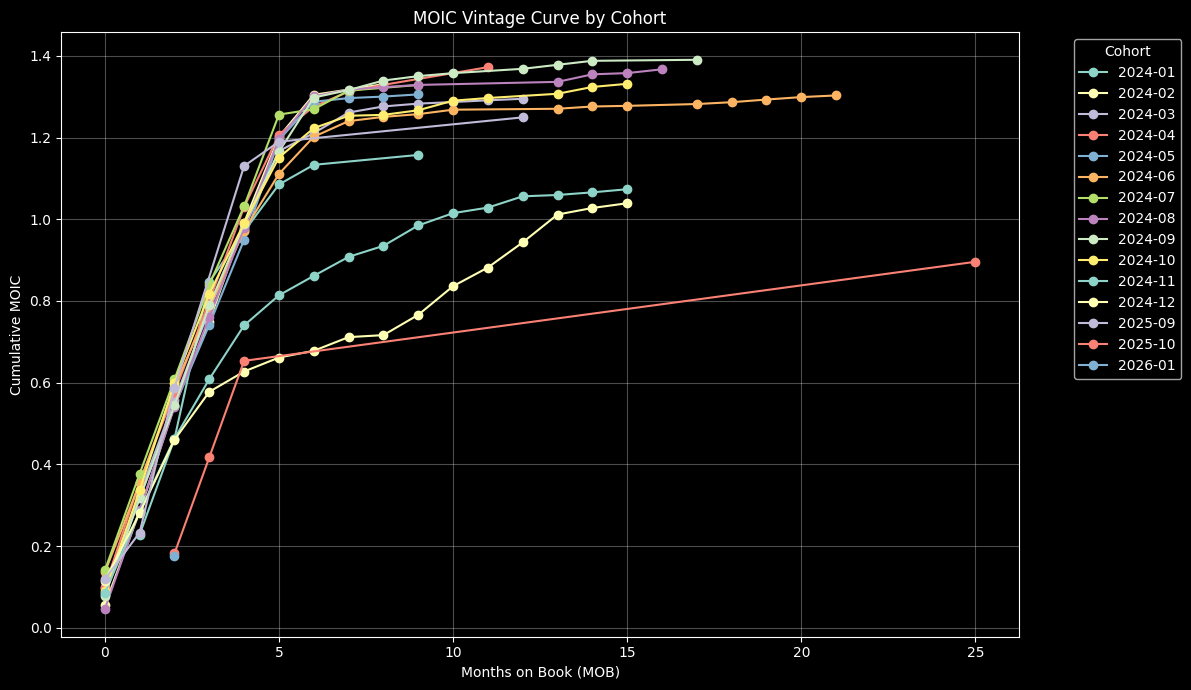

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

for cohort in sorted(cohort_moic["Cohort"].unique()):

    cohort_data = cohort_moic[
        cohort_moic["Cohort"] == cohort
    ]

    plt.plot(
        cohort_data["MOB"],
        cohort_data["Cumulative MOIC"],
        marker="o",
        label=str(cohort)
    )

plt.title("MOIC Vintage Curve by Cohort")
plt.xlabel("Months on Book (MOB)")
plt.ylabel("Cumulative MOIC")
plt.grid(True, alpha=0.3)
plt.legend(title="Cohort", bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.show()